# Auditoría y preprocesamiento de datos

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [105]:
ruta = "../creditSIM.xlsx"

df_modelo = pd.read_excel(ruta, sheet_name="modelo")
df_prediccion = pd.read_excel(ruta, sheet_name="prediccion")

In [106]:
print("Dimensión hoja modelo:", df_modelo.shape)
print("Dimensión hoja predicción:", df_prediccion.shape)

Dimensión hoja modelo: (3000, 11)
Dimensión hoja predicción: (1000, 10)


In [107]:
display(df_modelo.head())

,ID,AgnosDirec,AgnosEmpleo,DeudaExt,DeudaInt,Edad,Ingreso,Ingreso2,Nacionalidad,NivelEdu,VarObj
0,100001,4.00,2.00,"9,561.98","7,660.04",40.00,"64,117.45","44,473.10",N,SupInc,S
1,100002,28.00,25.00,"11,985.89","6,872.03",49.00,"124,062.09","84,958.10",N,Med,N
2,100003,2.00,3.00,"1,028.36","1,075.60",38.00,"32,010.88","27,638.82",N,SupCom,N
3,100004,11.00,14.00,"10,974.30","2,377.43",43.00,"172,337.44","125,056.57",N,Bas,N
4,100005,3.00,1.00,842.81,"1,142.83",33.00,"25,937.76","23,755.32",N,SupInc,S


In [108]:
print(df_modelo.columns.tolist())

['ID', 'AgnosDirec', 'AgnosEmpleo', 'DeudaExt', 'DeudaInt', 'Edad', 'Ingreso', 'Ingreso2', 'Nacionalidad', 'NivelEdu', 'VarObj']


# Tipo de datos

In [109]:
tipos_datos = pd.DataFrame({
    "Variable": df_modelo.columns,
    "Tipo": df_modelo.dtypes.astype(str).values
})

display(tipos_datos)

,Variable,Tipo
0,ID,int64
1,AgnosDirec,float64
2,AgnosEmpleo,float64
3,DeudaExt,float64
4,DeudaInt,float64
5,Edad,float64
6,Ingreso,float64
7,Ingreso2,float64
8,Nacionalidad,str
9,NivelEdu,str


# Cardinalidad

In [110]:
variables_categoricas = df_modelo.select_dtypes(
    include=["object", "category"]
).columns

cardinalidad = pd.DataFrame({
    "Variable": variables_categoricas,
    "Cantidad_categorias": [
        df_modelo[col].nunique(dropna=False)
        for col in variables_categoricas
    ],
    "Categorias": [
        df_modelo[col].unique().tolist()
        for col in variables_categoricas
    ]
})

display(cardinalidad)

/var/folders/hn/9dqbv4n95hb4_33xs6sw21xr0000gn/T/ipykernel_2720/2598289974.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df_modelo.select_dtypes(


,Variable,Cantidad_categorias,Categorias
0,Nacionalidad,1,[N]
1,NivelEdu,5,"[SupInc, Med, SupCom, Bas, Posg]"
2,VarObj,2,"[S, N]"


In [111]:
for columna in variables_categoricas:
    print(f"\nFrecuencias de {columna}")
    
    frecuencias = df_modelo[columna].value_counts(
        dropna=False
    ).to_frame("Frecuencia")
    
    frecuencias["Porcentaje"] = (
        frecuencias["Frecuencia"] / len(df_modelo) * 100
    )
    
    display(frecuencias)


Frecuencias de Nacionalidad


,Frecuencia,Porcentaje
Nacionalidad,,
N,3000,100.00



Frecuencias de NivelEdu


,Frecuencia,Porcentaje
NivelEdu,,
SupCom,979,32.63
SupInc,967,32.23
Med,632,21.07
Bas,243,8.10
Posg,179,5.97



Frecuencias de VarObj


,Frecuencia,Porcentaje
VarObj,,
N,2363,78.77
S,637,21.23


# Valores nulos

In [112]:
resumen_nulos = pd.DataFrame({
    "Cantidad_nulos": df_modelo.isna().sum(),
    "Porcentaje_nulos": df_modelo.isna().mean() * 100
}).sort_values("Cantidad_nulos", ascending=False)

display(resumen_nulos)

,Cantidad_nulos,Porcentaje_nulos
DeudaInt,4,0.13
AgnosEmpleo,2,0.07
Edad,2,0.07
Ingreso,2,0.07
AgnosDirec,1,0.03
DeudaExt,1,0.03
ID,0,0.00
Ingreso2,0,0.00
Nacionalidad,0,0.00
NivelEdu,0,0.00


In [113]:
filas_con_nulos = df_modelo.isna().any(axis=1).sum()
porcentaje_filas_nulas = filas_con_nulos / len(df_modelo) * 100

print("Filas con al menos un valor nulo:", filas_con_nulos)
print(f"Porcentaje de filas afectadas: {porcentaje_filas_nulas:.2f}%")

Filas con al menos un valor nulo: 12
Porcentaje de filas afectadas: 0.40%


# Estadística descriptiva

In [114]:
resumen_numerico = df_modelo.describe().T

resumen_numerico["mediana"] = df_modelo.select_dtypes(
    include=np.number
).median()

resumen_numerico["asimetria"] = df_modelo.select_dtypes(
    include=np.number
).skew()

resumen_numerico["curtosis"] = df_modelo.select_dtypes(
    include=np.number
).kurtosis()

display(resumen_numerico)

,count,mean,std,min,25%,50%,75%,max,mediana,asimetria,curtosis
ID,"3,000.00","101,500.50",866.17,"100,001.00","100,750.75","101,500.50","102,250.25","103,000.00","101,500.50",0.00,-1.20
AgnosDirec,"2,999.00",7.09,6.96,0.00,2.00,5.00,10.00,61.00,5.00,1.89,5.04
AgnosEmpleo,"2,998.00",7.15,6.65,0.00,2.00,5.00,10.00,47.00,5.00,1.56,3.02
DeudaExt,"2,999.00","4,531.01","7,084.78",21.55,"1,110.24","2,278.66","5,093.77","123,939.24","2,278.66",5.84,57.76
DeudaInt,"2,996.00","2,275.68","5,409.79",8.30,416.04,958.28,"2,318.27","190,648.85",958.28,16.83,507.86
Edad,"2,998.00",37.66,36.63,18.00,29.00,36.50,44.00,"1,970.00",36.50,49.00,"2,584.97"
Ingreso,"2,998.00","62,567.74","49,385.68","-13,123.60","30,282.68","49,516.13","78,851.47","536,488.40","49,516.13",2.84,14.59
Ingreso2,"3,000.00","52,152.67","42,246.04","-9,723.72","25,109.56","40,632.27","66,206.20","513,618.59","40,632.27",3.03,16.95


In [115]:
variables_numericas = [
    "AgnosDirec",
    "AgnosEmpleo",
    "DeudaExt",
    "DeudaInt",
    "Edad",
    "Ingreso",
    "Ingreso2"
]

display(df_modelo[variables_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
AgnosDirec,"2,999.00",7.09,6.96,0.00,2.00,5.00,10.00,61.00
AgnosEmpleo,"2,998.00",7.15,6.65,0.00,2.00,5.00,10.00,47.00
DeudaExt,"2,999.00","4,531.01","7,084.78",21.55,"1,110.24","2,278.66","5,093.77","123,939.24"
DeudaInt,"2,996.00","2,275.68","5,409.79",8.30,416.04,958.28,"2,318.27","190,648.85"
Edad,"2,998.00",37.66,36.63,18.00,29.00,36.50,44.00,"1,970.00"
Ingreso,"2,998.00","62,567.74","49,385.68","-13,123.60","30,282.68","49,516.13","78,851.47","536,488.40"
Ingreso2,"3,000.00","52,152.67","42,246.04","-9,723.72","25,109.56","40,632.27","66,206.20","513,618.59"


# Estrategia de imputación

In [116]:
df = df_modelo.copy()

In [117]:
medianas_imputacion = {}

for columna in variables_numericas:
    mediana = df[columna].median()
    medianas_imputacion[columna] = mediana
    df[columna] = df[columna].fillna(mediana)

In [118]:
medianas_imputacion = pd.Series(
    medianas_imputacion,
    name="Mediana utilizada"
)

display(medianas_imputacion.to_frame())

,Mediana utilizada
AgnosDirec,5.00
AgnosEmpleo,5.00
DeudaExt,"2,278.66"
DeudaInt,958.28
Edad,36.50
Ingreso,"49,516.13"
Ingreso2,"40,632.27"


In [119]:
print("Total de valores nulos después de imputar:")
print(df[variables_numericas].isna().sum().sum())

Total de valores nulos después de imputar:
0


In [120]:
var_obj = df["VarObj"].copy()
id_cliente = df["ID"].copy()

In [121]:
X_original = df.drop(columns=["ID", "VarObj"])

display(X_original.head())

,AgnosDirec,AgnosEmpleo,DeudaExt,DeudaInt,Edad,Ingreso,Ingreso2,Nacionalidad,NivelEdu
0,4.00,2.00,"9,561.98","7,660.04",40.00,"64,117.45","44,473.10",N,SupInc
1,28.00,25.00,"11,985.89","6,872.03",49.00,"124,062.09","84,958.10",N,Med
2,2.00,3.00,"1,028.36","1,075.60",38.00,"32,010.88","27,638.82",N,SupCom
3,11.00,14.00,"10,974.30","2,377.43",43.00,"172,337.44","125,056.57",N,Bas
4,3.00,1.00,842.81,"1,142.83",33.00,"25,937.76","23,755.32",N,SupInc


La hoja modelo contiene 3.000 clientes y 11 variables. Se identificaron variables numéricas asociadas con edad, antigüedad, ingresos y deuda, además de variables
categóricas relacionadas con nacionalidad, educación y bancarrota. La variable ID fue excluida porque solo corresponde a un identificador, mientras que VarObj se separó porque no puede utilizarse para construir los clusters.

Se encontraron pocos valores nulos, cuatro en DeudaInt, dos en AgnosEmpleo, Edad e Ingreso, y uno en AgnosDirec y DeudaExt. Debido a que representan una proporción muy baja de las 3.000 observaciones, no se eliminaron filas. Los valores faltantes fueron reemplazados por la mediana de cada variable, ya que esta medida es robusta frente a posibles valores extremos en ingresos y deudas.
De esta manera se conserva prácticamente toda la información disponible antes de realizar el análisis de clustering.

# Análisis de Ingreso e Ingreso2

## Correlación

In [122]:
df[["Ingreso","Ingreso2"]].corr()

,Ingreso,Ingreso2
Ingreso,1.00,0.98
Ingreso2,0.98,1.00


In [123]:
correlacion = df["Ingreso"].corr(df["Ingreso2"])

print(f"Correlación: {correlacion:.4f}")

Correlación: 0.9835


# Gráfico de dispersión

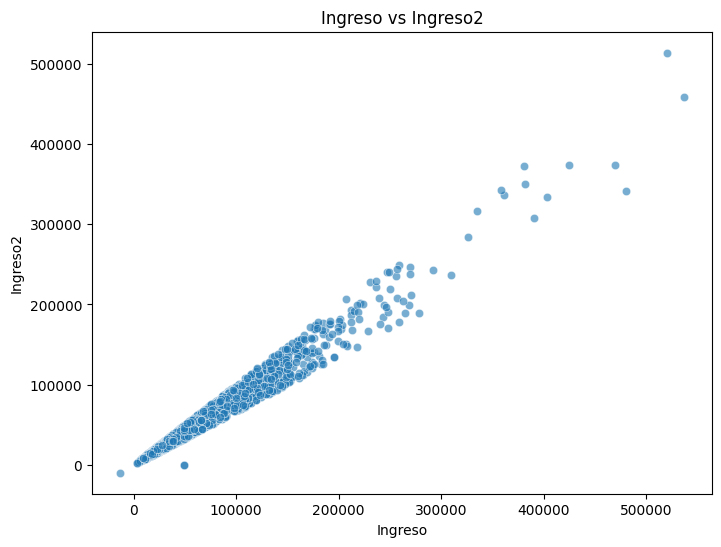

In [124]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Ingreso",
    y="Ingreso2",
    alpha=0.6
)

plt.title("Ingreso vs Ingreso2")
plt.xlabel("Ingreso")
plt.ylabel("Ingreso2")

plt.show()

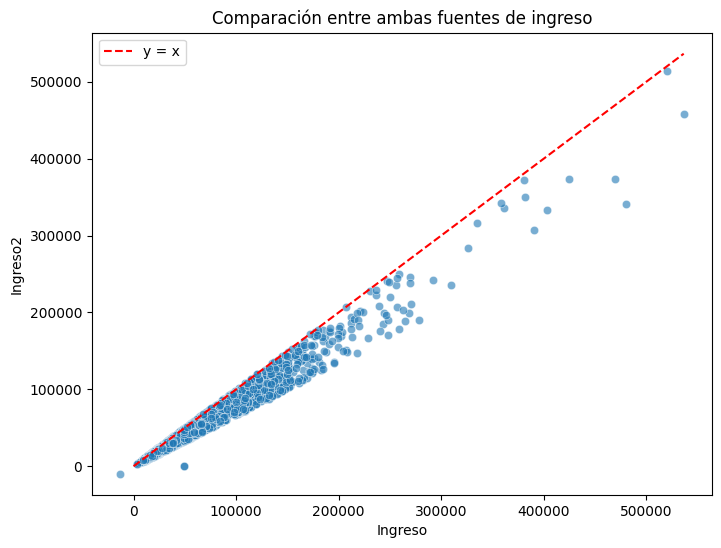

In [125]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Ingreso",
    y="Ingreso2",
    alpha=0.6
)

limite = max(df["Ingreso"].max(), df["Ingreso2"].max())

plt.plot(
    [0, limite],
    [0, limite],
    color="red",
    linestyle="--",
    label="y = x"
)

plt.legend()

plt.title("Comparación entre ambas fuentes de ingreso")

plt.show()

In [126]:
df["Dif_Ingreso"] = df["Ingreso2"] - df["Ingreso"]

In [127]:
df["Dif_Ingreso"].describe()

count      3,000.00
mean     -10,406.37
std       10,930.83
min     -139,037.66
25%      -13,988.44
50%       -7,150.62
75%       -3,297.26
max        3,399.88
Name: Dif_Ingreso, dtype: float64

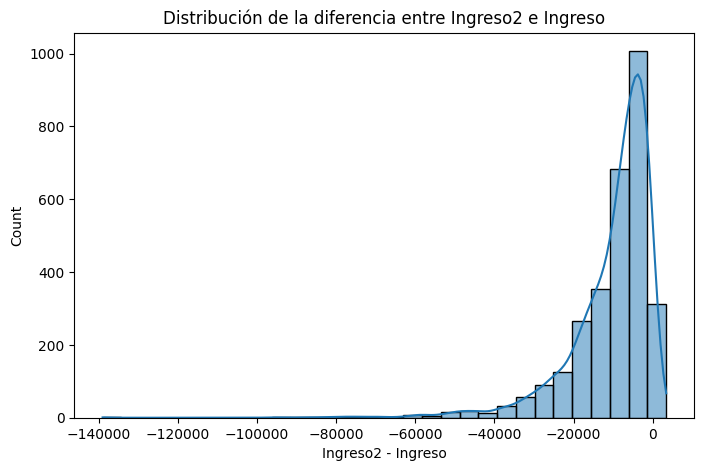

In [128]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Dif_Ingreso"],
    bins=30,
    kde=True
)

plt.title("Distribución de la diferencia entre Ingreso2 e Ingreso")

plt.xlabel("Ingreso2 - Ingreso")

plt.show()

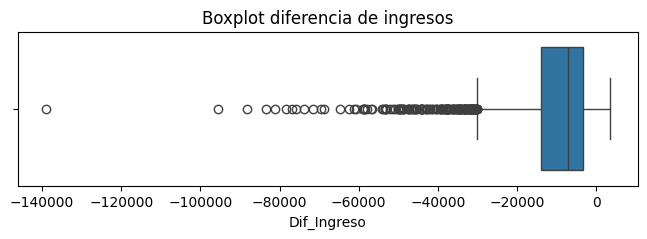

In [129]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["Dif_Ingreso"])

plt.title("Boxplot diferencia de ingresos")

plt.show()

In [130]:
print("Promedio diferencia:", df["Dif_Ingreso"].mean())

print("Mediana diferencia:", df["Dif_Ingreso"].median())

print("Desv. estándar:", df["Dif_Ingreso"].std())


Promedio diferencia: -10406.374830547666
Mediana diferencia: -7150.619725705084
Desv. estándar: 10930.829871177888


In [131]:
df["Ingreso_Promedio"] = (
    df["Ingreso"] +
    df["Ingreso2"]
) / 2

In [132]:
df[
    [
        "Ingreso",
        "Ingreso2",
        "Ingreso_Promedio"
    ]
].head()

,Ingreso,Ingreso2,Ingreso_Promedio
0,"64,117.45","44,473.10","54,295.27"
1,"124,062.09","84,958.10","104,510.09"
2,"32,010.88","27,638.82","29,824.85"
3,"172,337.44","125,056.57","148,697.00"
4,"25,937.76","23,755.32","24,846.54"


La correlación entre Ingreso e Ingreso2 es muy alta, lo que indica que ambas variables entregan información similar sobre la capacidad económica del cliente. El gráfico de dispersión muestra una relación aproximadamente lineal y cercana a la diagonal, aunque existen pequeñas diferencias entre ambas mediciones.
Al analizar la variable Dif_Ingreso, se observa que la mayoría de las diferencias son reducidas y se concentran alrededor de cero, sin evidenciar un sesgo importante entre ambas fuentes.
Para aprovechar la información disponible y disminuir el efecto de posibles errores de medición, se utilizará la variable Ingreso_Promedio, calculada como el promedio de ambas fuentes de ingreso. Esta nueva variable representa de mejor manera el nivel de ingresos del cliente y será utilizada en las siguientes etapas del análisis.

In [133]:
df = df.drop(columns=["Ingreso", "Ingreso2"])

In [134]:
variables = [
    "AgnosDirec",
    "AgnosEmpleo",
    "DeudaExt",
    "DeudaInt",
    "Edad",
    "Ingreso_Promedio"
]

# Detección y tratamiento de outliers

In [135]:
variables_continuas = [
    "AgnosDirec",
    "AgnosEmpleo",
    "DeudaExt",
    "DeudaInt",
    "Edad",
    "Ingreso_Promedio"
]

# Método 1: IQR

In [136]:
outliers_iqr = {}

for col in variables_continuas:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    n = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()

    outliers_iqr[col] = n

pd.DataFrame.from_dict(
    outliers_iqr,
    orient="index",
    columns=["Outliers IQR"]
)

,Outliers IQR
AgnosDirec,123
AgnosEmpleo,99
DeudaExt,287
DeudaInt,277
Edad,8
Ingreso_Promedio,152


# Método 2: Z-score robusto (MAD)

In [137]:
from scipy.stats import median_abs_deviation

outliers_mad = {}

for col in variables_continuas:

    mediana = df[col].median()

    mad = median_abs_deviation(df[col])

    robust_z = 0.6745 * (df[col] - mediana) / mad

    n = (np.abs(robust_z) > 3.5).sum()

    outliers_mad[col] = n

pd.DataFrame.from_dict(
    outliers_mad,
    orient="index",
    columns=["Outliers MAD"]
)

,Outliers MAD
AgnosDirec,174
AgnosEmpleo,149
DeudaExt,318
DeudaInt,331
Edad,1
Ingreso_Promedio,120


In [138]:
comparacion = pd.DataFrame({
    "IQR":outliers_iqr,
    "MAD":outliers_mad
})

comparacion

,IQR,MAD
AgnosDirec,123,174
AgnosEmpleo,99,149
DeudaExt,287,318
DeudaInt,277,331
Edad,8,1
Ingreso_Promedio,152,120


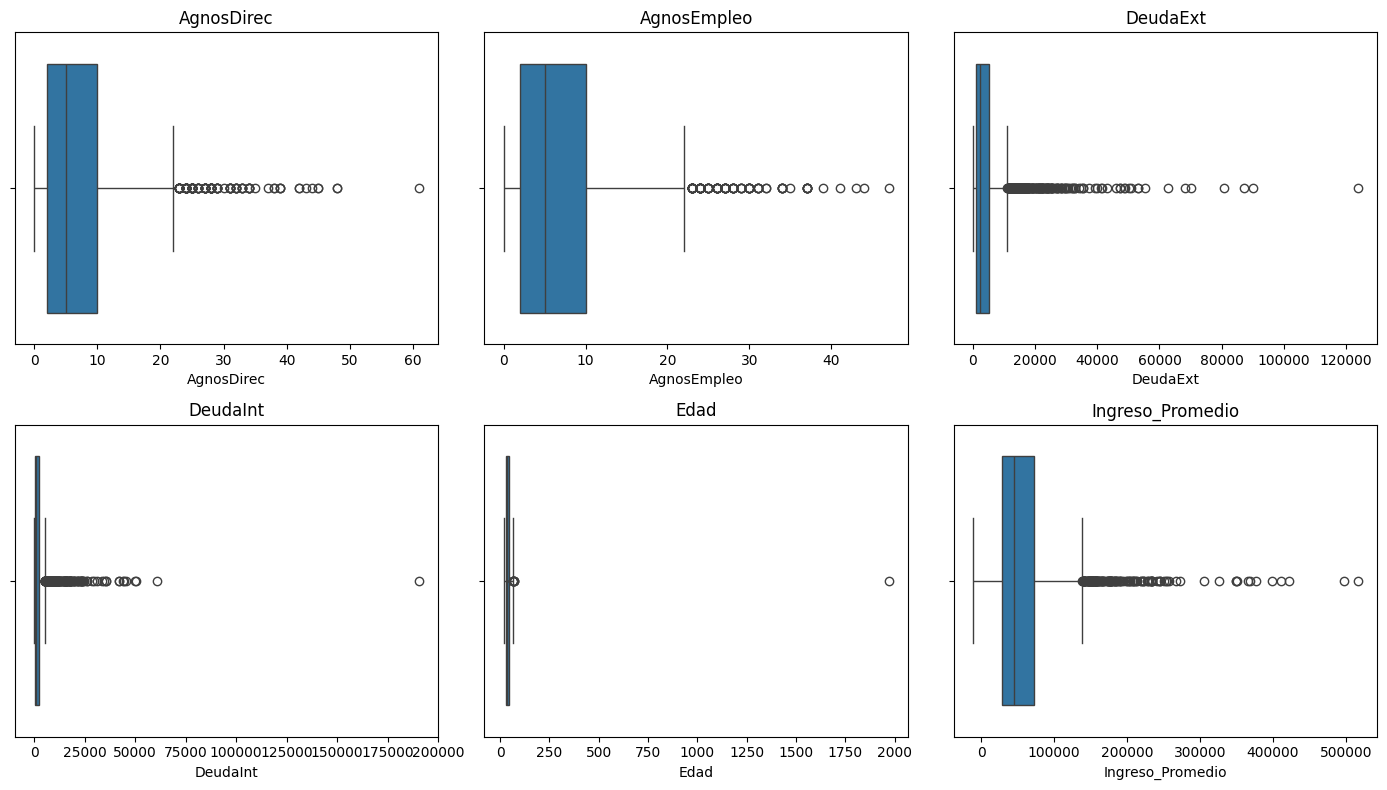

In [139]:
fig, axes = plt.subplots(2,3,figsize=(14,8))

axes = axes.flatten()

for ax, col in zip(axes, variables_continuas):

    sns.boxplot(x=df[col], ax=ax)

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [140]:
df_cluster = df.copy()

In [141]:
for col in variables_continuas:

    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5*IQR
    limite_sup = Q3 + 1.5*IQR

    df_cluster[col] = df_cluster[col].clip(
        lower=limite_inf,
        upper=limite_sup
    )

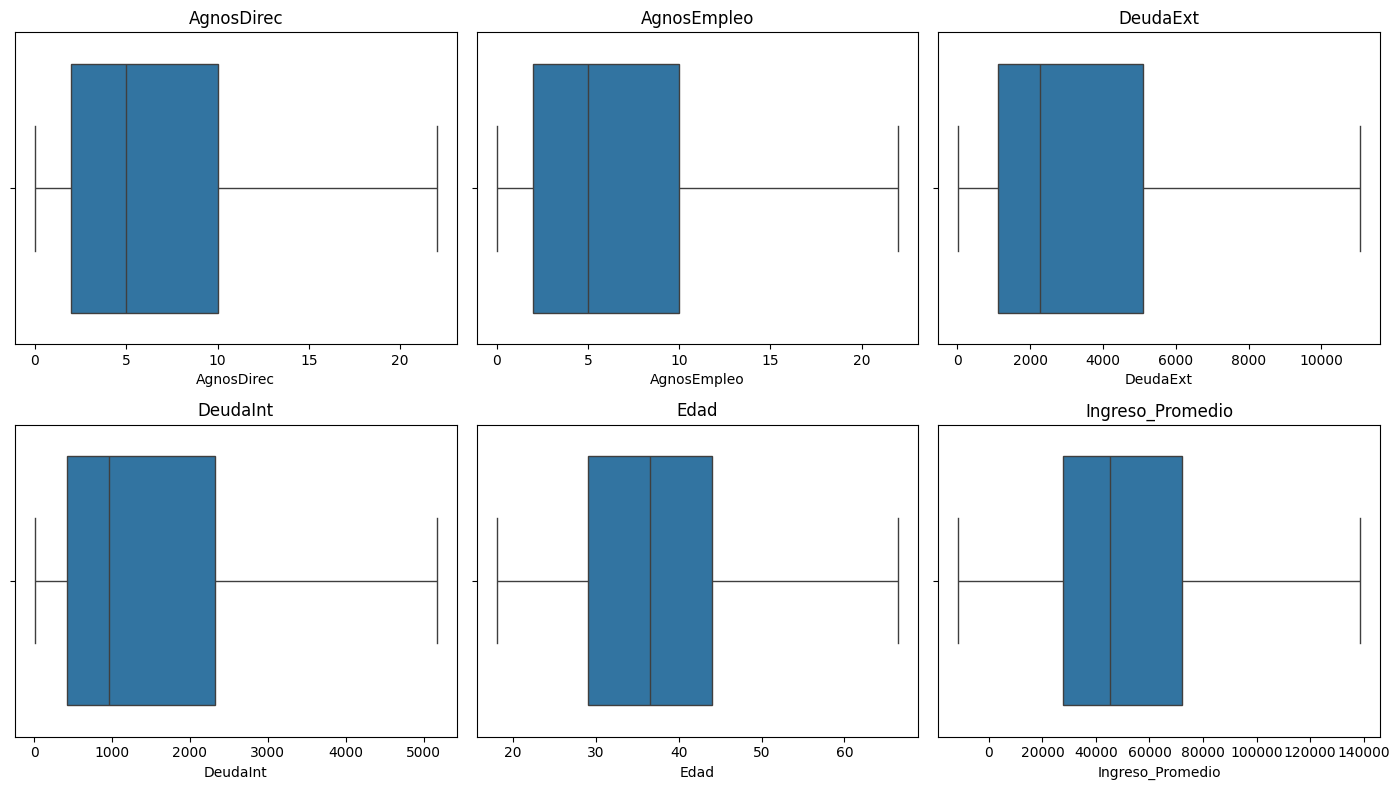

In [142]:
fig, axes = plt.subplots(2,3,figsize=(14,8))

axes = axes.flatten()

for ax, col in zip(axes, variables_continuas):

    sns.boxplot(x=df_cluster[col], ax=ax)

    ax.set_title(col)

plt.tight_layout()

plt.show()

In [143]:
print("Observaciones originales:", len(df))

print("Observaciones finales:", len(df_cluster))

Observaciones originales: 3000
Observaciones finales: 3000


Se evaluaron valores atípicos utilizando dos métodos, el criterio del rango intercuartílico (IQR) y el Z-score robusto basado en la desviación absoluta mediana (MAD). Ambos métodos detectaron observaciones extremas principalmente en las variables de ingresos y deuda, lo cual es esperable en información financiera.
En lugar de eliminar clientes, se aplicó winsorización utilizando los límites definidos por el criterio IQR. Esta decisión permite reducir la influencia de valores extremos sobre la distancia euclidiana utilizada por algoritmos como K-Means, manteniendo todas las observaciones del conjunto de datos.
Esta estrategia evita perder información relevante y genera una base más estable para las siguientes etapas del análisis.

# Construcción de variables derivadas

## Variable 1: Deuda Total

In [144]:
df_cluster["Deuda_Total"] = (
    df_cluster["DeudaExt"] +
    df_cluster["DeudaInt"]
)

## Variable 2: Ratio de Endeudamiento

In [145]:
df_cluster["Ratio_Endeudamiento"] = (
    df_cluster["Deuda_Total"] /
    df_cluster["Ingreso_Promedio"]
)

## Variable 3: Proporción de Deuda Interna

In [146]:
df_cluster["Prop_DeudaInt"] = (
    df_cluster["DeudaInt"] /
    df_cluster["Deuda_Total"]
)

In [147]:
df_cluster["Prop_DeudaInt"] = (
    df_cluster["Prop_DeudaInt"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [148]:
df_cluster[
    [
        "DeudaExt",
        "DeudaInt",
        "Deuda_Total",
        "Ratio_Endeudamiento",
        "Prop_DeudaInt"
    ]
].head()

,DeudaExt,DeudaInt,Deuda_Total,Ratio_Endeudamiento,Prop_DeudaInt
0,"9,561.98","5,167.72","14,729.70",0.27,0.35
1,"11,059.25","5,167.72","16,226.97",0.16,0.32
2,"1,028.36","1,075.60","2,103.96",0.07,0.51
3,"10,974.30","2,377.43","13,351.73",0.10,0.18
4,842.81,"1,142.83","1,985.63",0.08,0.58


## Estadísticas descriptivas

In [149]:
nuevas_variables = [
    "Deuda_Total",
    "Ratio_Endeudamiento",
    "Prop_DeudaInt"
]

df_cluster[nuevas_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Deuda_Total,"3,000.00","5,226.61","4,641.14",29.85,"1,670.96","3,493.35","7,487.34","16,226.97"
Ratio_Endeudamiento,"3,000.00",0.09,0.07,-0.13,0.05,0.08,0.12,0.50
Prop_DeudaInt,"3,000.00",0.31,0.14,0.02,0.20,0.30,0.40,0.85


## Distribución de las variables

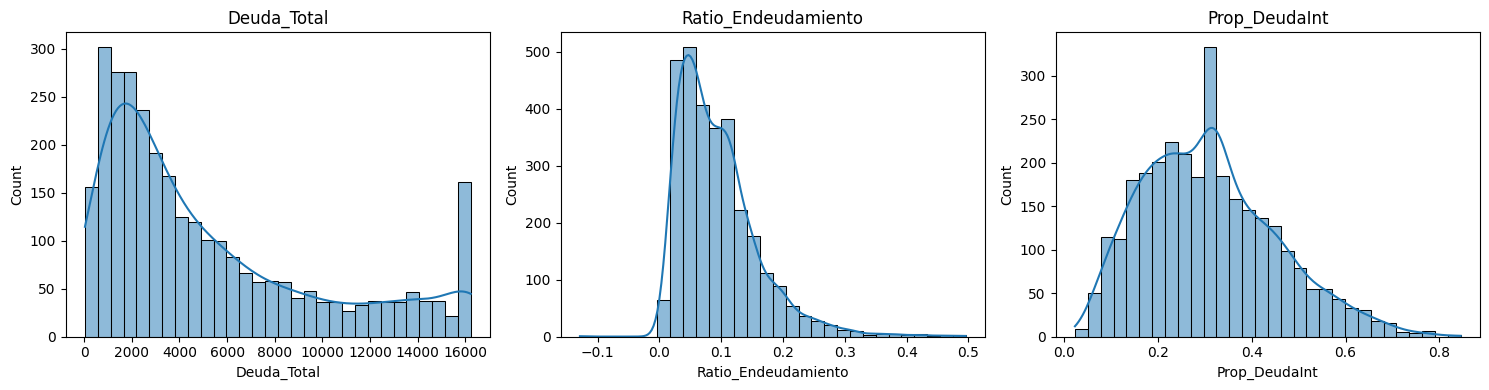

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, nuevas_variables):

    sns.histplot(
        df_cluster[col],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

Se construyeron tres variables derivadas con el objetivo de representar mejor el perfil financiero de los clientes. La primera corresponde a la Deuda Total, obtenida como la suma de la deuda interna y externa. La segunda es el Ratio de Endeudamiento, que relaciona la deuda total con el ingreso promedio del cliente y permite aproximar su nivel de apalancamiento financiero. Finalmente, se calculó la Proporción de Deuda Interna, que mide qué fracción de la deuda total corresponde a obligaciones con el banco.
Estas variables entregan información más representativa que las variables originales por separado, ya que describen la carga financiera relativa del cliente y podrían facilitar una mejor separación de perfiles durante el proceso de clustering.

# Codificación de Variables Mixtas y Escalamiento

In [151]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [152]:
variables_numericas = [
    "AgnosDirec",
    "AgnosEmpleo",
    "Edad",
    "Ingreso_Promedio",
    "DeudaExt",
    "DeudaInt",
    "Deuda_Total",
    "Ratio_Endeudamiento",
    "Prop_DeudaInt"
]

variables_categoricas = [
    "Nacionalidad",
    "NivelEdu"
]

In [153]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), variables_numericas),
        ("cat", OneHotEncoder(drop="first"), variables_categoricas)
    ]
)

In [154]:
X_preparado = preprocesador.fit_transform(df_cluster)

In [155]:
print(X_preparado.shape)

(3000, 13)


In [156]:
columnas = preprocesador.get_feature_names_out()

columnas

array(['num__AgnosDirec', 'num__AgnosEmpleo', 'num__Edad',
       'num__Ingreso_Promedio', 'num__DeudaExt', 'num__DeudaInt',
       'num__Deuda_Total', 'num__Ratio_Endeudamiento',
       'num__Prop_DeudaInt', 'cat__NivelEdu_Med', 'cat__NivelEdu_Posg',
       'cat__NivelEdu_SupCom', 'cat__NivelEdu_SupInc'], dtype=object)

In [157]:
X_preparado = pd.DataFrame(
    X_preparado,
    columns=columnas
)

X_preparado.head()

,num__AgnosDirec,num__AgnosEmpleo,num__Edad,num__Ingreso_Promedio,num__DeudaExt,num__DeudaInt,num__Deuda_Total,num__Ratio_Endeudamiento,num__Prop_DeudaInt,cat__NivelEdu_Med,cat__NivelEdu_Posg,cat__NivelEdu_SupCom,cat__NivelEdu_SupInc
0,-0.12,-0.38,0.23,0.21,1.83,2.22,1.93,2.48,0.25,0.00,0.00,0.00,1.00
1,2.12,2.12,0.83,1.34,2.21,2.22,2.19,0.97,0.09,1.00,0.00,0.00,0.00
2,-0.38,-0.25,0.10,-0.35,-0.31,0.06,-0.24,-0.14,1.07,0.00,0.00,1.00,0.00
3,0.75,1.12,0.43,2.11,2.19,0.75,1.69,0.20,-0.63,0.00,0.00,0.00,0.00
4,-0.25,-0.50,-0.23,-0.46,-0.36,0.10,-0.26,-0.02,1.40,0.00,0.00,0.00,1.00


In [158]:
X_preparado.describe().T

,count,mean,std,min,25%,50%,75%,max
num__AgnosDirec,"3,000.00",0.23,0.75,-0.62,-0.38,0.00,0.62,2.12
num__AgnosEmpleo,"3,000.00",0.24,0.75,-0.62,-0.38,0.00,0.62,2.12
num__Edad,"3,000.00",0.03,0.65,-1.23,-0.50,0.00,0.50,2.00
num__Ingreso_Promedio,"3,000.00",0.21,0.78,-1.27,-0.39,-0.00,0.61,2.11
num__DeudaExt,"3,000.00",0.34,0.84,-0.57,-0.29,0.00,0.71,2.21
num__DeudaInt,"3,000.00",0.34,0.83,-0.50,-0.28,0.00,0.72,2.22
num__Deuda_Total,"3,000.00",0.30,0.80,-0.60,-0.31,0.00,0.69,2.19
num__Ratio_Endeudamiento,"3,000.00",0.18,0.85,-2.73,-0.45,0.00,0.55,5.41
num__Prop_DeudaInt,"3,000.00",0.04,0.73,-1.42,-0.51,0.00,0.49,2.78
cat__NivelEdu_Med,"3,000.00",0.21,0.41,0.00,0.00,0.00,0.00,1.00


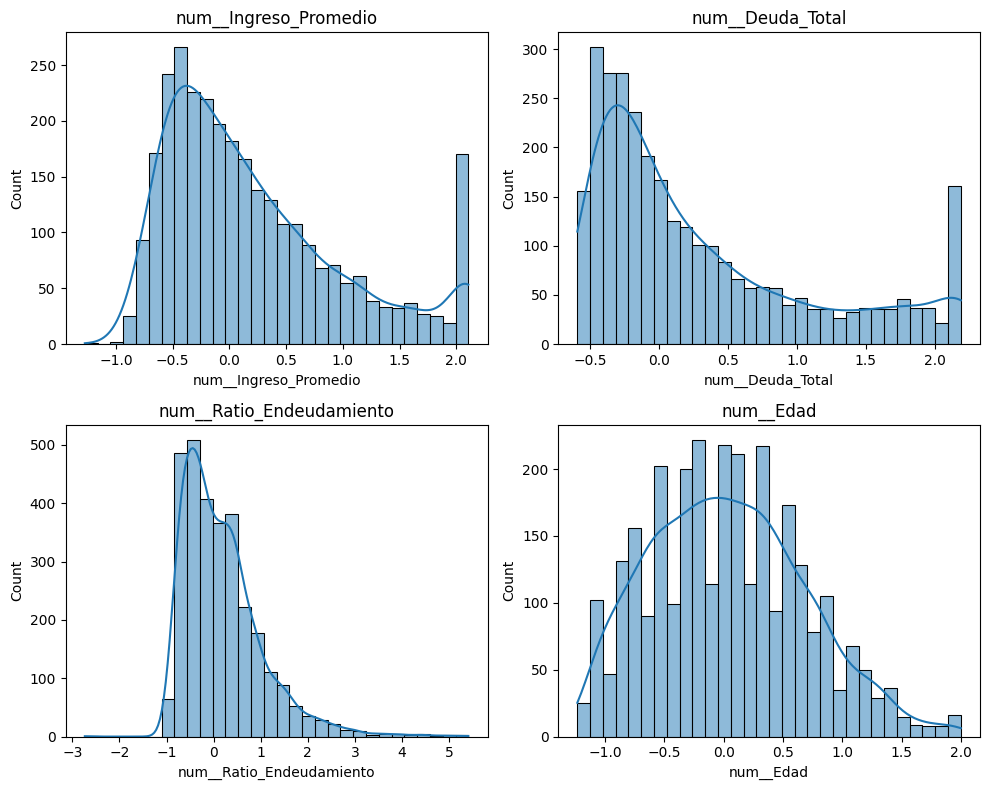

In [159]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

variables = [
    "num__Ingreso_Promedio",
    "num__Deuda_Total",
    "num__Ratio_Endeudamiento",
    "num__Edad"
]

for ax, var in zip(axes.flatten(), variables):

    sns.histplot(
        X_preparado[var],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(var)

plt.tight_layout()
plt.show()

In [160]:
print("Número de variables finales:", X_preparado.shape[1])

print("Número de clientes:", X_preparado.shape[0])

Número de variables finales: 13
Número de clientes: 3000


Las variables numéricas fueron escaladas utilizando RobustScaler, debido a que durante la etapa de auditoría se detectó la presencia de valores extremos. Este método utiliza la mediana y el rango intercuartílico, por lo que resulta menos sensible a outliers que StandardScaler.
Las variables categóricas fueron transformadas mediante One-Hot Encoding, permitiendo que algoritmos basados en distancia puedan trabajar con ellas sin asumir un orden entre las categorías.
Finalmente, se obtuvo una matriz completamente numérica que será utilizada en las siguientes etapas de reducción de dimensionalidad y clustering.

# Reducción de Dimensionalidad

In [161]:
from sklearn.decomposition import PCA

In [162]:
pca = PCA()

X_pca = pca.fit_transform(X_preparado)

In [163]:
varianza = pd.DataFrame({
    "Componente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza": pca.explained_variance_ratio_,
    "Varianza Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

varianza

,Componente,Varianza,Varianza Acumulada
0,1,0.47,0.47
1,2,0.14,0.61
2,3,0.11,0.72
3,4,0.07,0.79
4,5,0.05,0.85
5,6,0.05,0.90
6,7,0.04,0.94
7,8,0.03,0.97
8,9,0.01,0.98
9,10,0.01,0.99


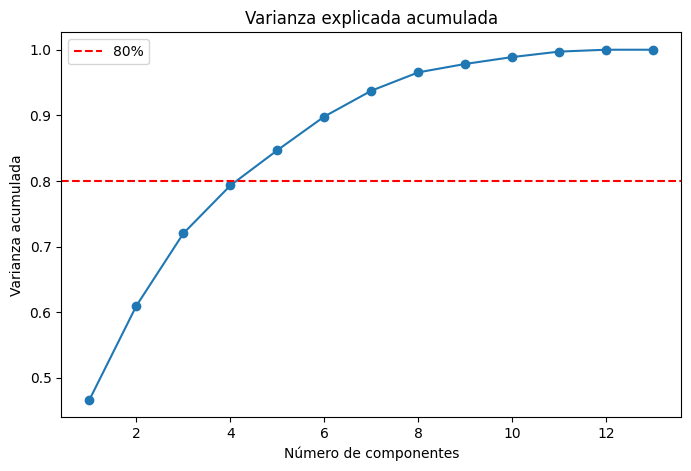

In [164]:
plt.figure(figsize=(8,5))

plt.plot(
    varianza["Componente"],
    varianza["Varianza Acumulada"],
    marker="o"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--",
    label="80%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.title("Varianza explicada acumulada")

plt.legend()

plt.show()

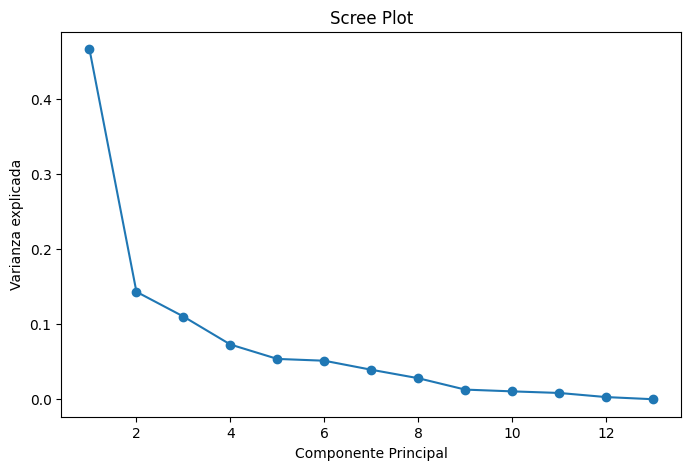

In [165]:
plt.figure(figsize=(8,5))

plt.plot(
    varianza["Componente"],
    varianza["Varianza"],
    marker="o"
)

plt.xlabel("Componente Principal")
plt.ylabel("Varianza explicada")

plt.title("Scree Plot")

plt.show()

In [166]:
n_componentes = np.argmax(
    np.cumsum(pca.explained_variance_ratio_) >= 0.80
) + 1

print(
    f"Componentes necesarios: {n_componentes}"
)

Componentes necesarios: 5


In [167]:
pca_final = PCA(
    n_components=n_componentes,
    random_state=42
)

X_pca = pca_final.fit_transform(X_preparado)

In [168]:
columnas_pca = [
    f"PC{i+1}"
    for i in range(n_componentes)
]

X_pca = pd.DataFrame(
    X_pca,
    columns=columnas_pca
)

X_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,2.69,2.34,0.88,0.44,-0.34
1,4.35,-0.80,-0.41,0.52,-0.09
2,-1.25,-0.04,1.00,0.39,0.76
3,2.77,-0.53,-0.96,-1.16,0.23
4,-1.33,0.08,1.39,0.45,-0.62


In [169]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=columnas_pca,
    index=X_preparado.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5
num__AgnosDirec,0.27,-0.37,-0.18,0.31,-0.29
num__AgnosEmpleo,0.30,-0.40,-0.23,0.19,-0.07
num__Edad,0.10,-0.24,-0.27,0.54,0.39
num__Ingreso_Promedio,0.35,-0.36,0.04,-0.49,0.08
num__DeudaExt,0.46,0.22,-0.16,-0.21,0.03
num__DeudaInt,0.43,0.02,0.42,0.01,0.07
num__Deuda_Total,0.46,0.16,0.03,-0.14,0.04
num__Ratio_Endeudamiento,0.30,0.63,-0.01,0.43,-0.08
num__Prop_DeudaInt,0.02,-0.22,0.80,0.29,-0.00
cat__NivelEdu_Med,0.01,0.01,-0.03,-0.01,-0.00


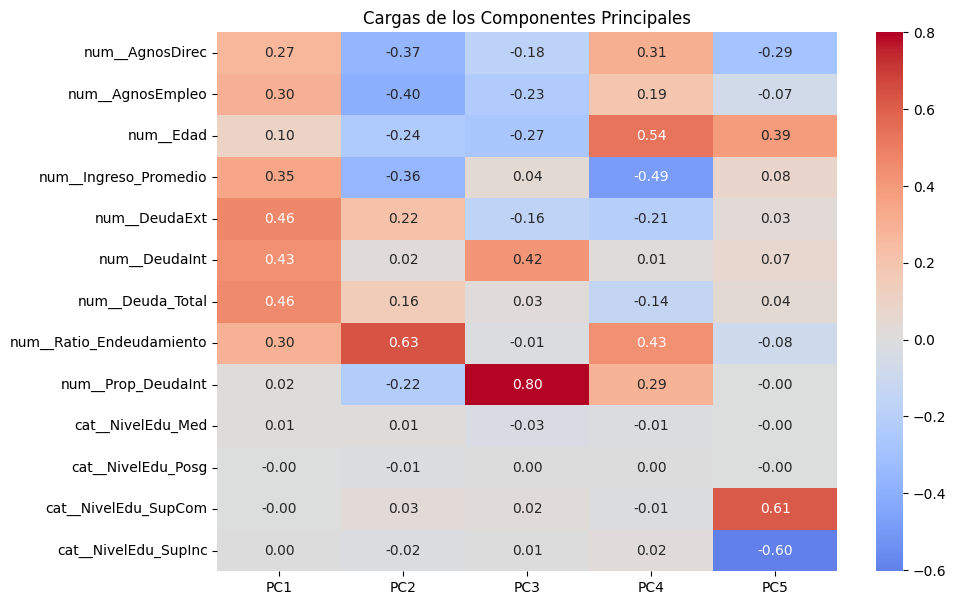

In [170]:
plt.figure(figsize=(10,7))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Cargas de los Componentes Principales")

plt.show()

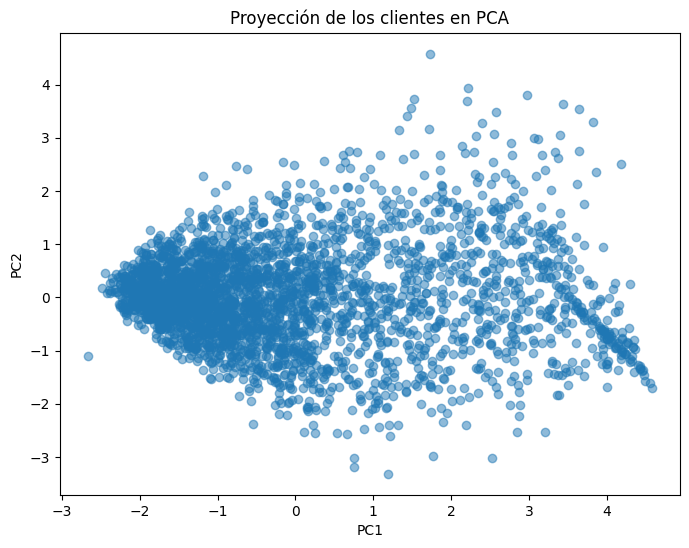

In [171]:
if n_componentes >= 2:

    plt.figure(figsize=(8,6))

    plt.scatter(
        X_pca["PC1"],
        X_pca["PC2"],
        alpha=0.5
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.title("Proyección de los clientes en PCA")

    plt.show()

Se aplicó Análisis de Componentes Principales (PCA) sobre la matriz de datos preprocesada con el objetivo de reducir la dimensionalidad y eliminar redundancia entre variables.
El gráfico de varianza acumulada permitió seleccionar el número mínimo de componentes necesarios para explicar aproximadamente el 80% de la variabilidad de los datos. Esto permite trabajar con una representación más compacta de la información sin perder una proporción importante de la variabilidad original.
Las cargas factoriales muestran qué variables contribuyen con mayor intensidad a cada componente principal, facilitando la interpretación de los factores que diferencian los distintos perfiles de clientes.

# Determinación del Número Óptimo de Clusters

In [172]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [173]:
k_values = range(2,11)

inercia = []
silhouette = []
calinski = []
davies = []

In [174]:
for k in k_values:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    etiquetas = modelo.fit_predict(X_pca)

    inercia.append(modelo.inertia_)

    silhouette.append(
        silhouette_score(
            X_pca,
            etiquetas
        )
    )

    calinski.append(
        calinski_harabasz_score(
            X_pca,
            etiquetas
        )
    )

    davies.append(
        davies_bouldin_score(
            X_pca,
            etiquetas
        )
    )

In [175]:
metricas = pd.DataFrame({
    "Clusters": list(k_values),
    "Inercia": inercia,
    "Silhouette": silhouette,
    "Calinski-Harabasz": calinski,
    "Davies-Bouldin": davies
})

metricas

,Clusters,Inercia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,"9,135.36",0.41,"2,091.71",1.10
1,3,"7,864.79",0.25,"1,456.50",1.58
2,4,"6,881.38",0.25,"1,252.12",1.47
3,5,"6,168.08",0.22,"1,133.92",1.47
4,6,"5,681.25",0.19,"1,035.86",1.49
5,7,"5,283.79",0.20,965.36,1.42
6,8,"5,008.91",0.19,896.03,1.42
7,9,"4,762.02",0.18,843.78,1.45
8,10,"4,558.03",0.17,798.20,1.42


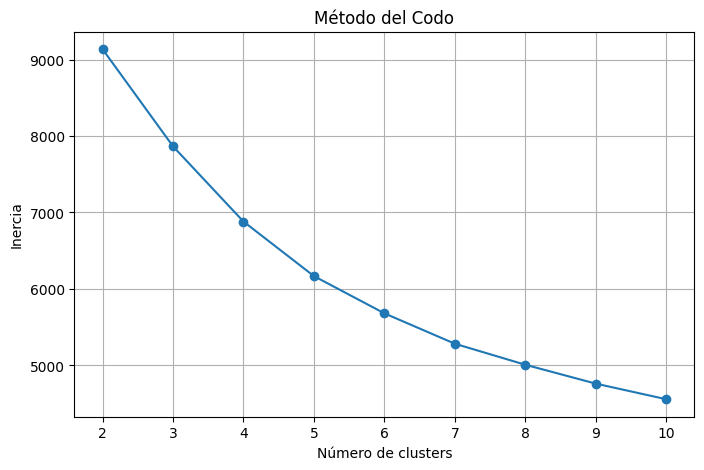

In [176]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["Clusters"],
    metricas["Inercia"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title("Método del Codo")

plt.grid(True)

plt.show()

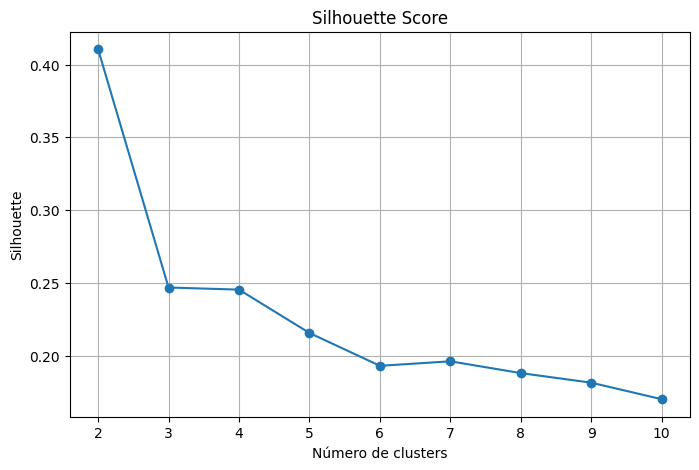

In [177]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["Clusters"],
    metricas["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")

plt.title("Silhouette Score")

plt.grid(True)

plt.show()

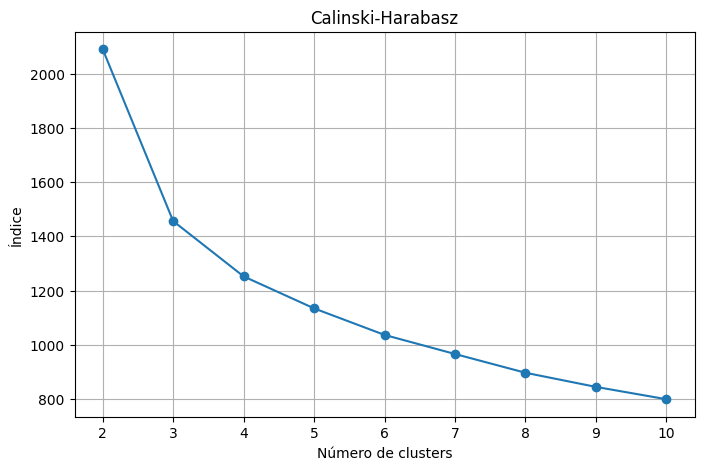

In [178]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["Clusters"],
    metricas["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Índice")

plt.title("Calinski-Harabasz")

plt.grid(True)

plt.show()

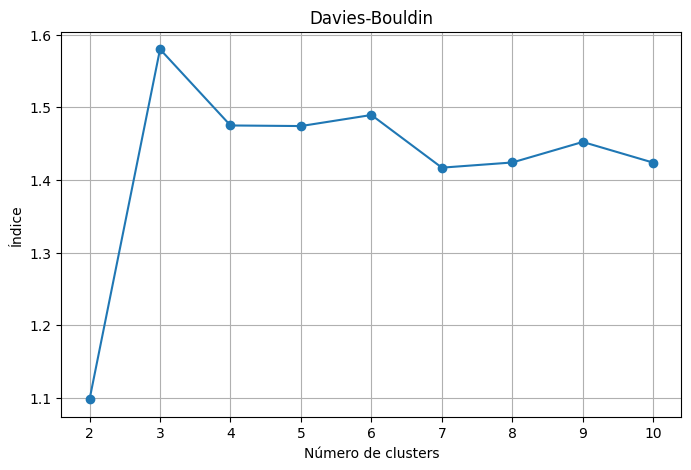

In [179]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["Clusters"],
    metricas["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Índice")

plt.title("Davies-Bouldin")

plt.grid(True)

plt.show()

In [180]:
print(
    "Mejor Silhouette:",
    metricas.loc[
        metricas["Silhouette"].idxmax(),
        "Clusters"
    ]
)

print(
    "Mejor Calinski:",
    metricas.loc[
        metricas["Calinski-Harabasz"].idxmax(),
        "Clusters"
    ]
)

print(
    "Mejor Davies:",
    metricas.loc[
        metricas["Davies-Bouldin"].idxmin(),
        "Clusters"
    ]
)

Mejor Silhouette: 2
Mejor Calinski: 2
Mejor Davies: 2


Se evaluaron distintas soluciones de clustering utilizando el método del codo, el índice Silhouette, Calinski-Harabasz y Davies-Bouldin. Los tres índices de validación coincidieron en que la mejor solución corresponde a dos clusters, lo que indica una separación clara entre dos grupos principales de clientes.
Aunque el método del codo mostró una disminución progresiva de la inercia al aumentar el número de grupos, las métricas de calidad favorecieron consistentemente la solución con k = 2, ya que presenta la mayor cohesión interna y la mejor separación entre los clusters. Por esta razón, se utilizarán dos grupos en el resto del análisis.

# Comparación de Algoritmos de Clustering

In [181]:
k_optimo = 2

## K-Means

In [182]:
from sklearn.cluster import KMeans

In [183]:
modelo_kmeans = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=20
)

cluster_kmeans = modelo_kmeans.fit_predict(X_pca)

In [184]:
df_cluster["Cluster_KMeans"] = cluster_kmeans

In [185]:
df_cluster["Cluster_KMeans"].value_counts().sort_index()

Cluster_KMeans
0     858
1    2142
Name: count, dtype: int64

In [186]:
sil_kmeans = silhouette_score(X_pca, cluster_kmeans)
cal_kmeans = calinski_harabasz_score(X_pca, cluster_kmeans)
dav_kmeans = davies_bouldin_score(X_pca, cluster_kmeans)

print(f"Silhouette K-Means: {sil_kmeans:.4f}")
print(f"Calinski-Harabasz K-Means: {cal_kmeans:.4f}")
print(f"Davies-Bouldin K-Means: {dav_kmeans:.4f}")

Silhouette K-Means: 0.4105
Calinski-Harabasz K-Means: 2091.7123
Davies-Bouldin K-Means: 1.0983


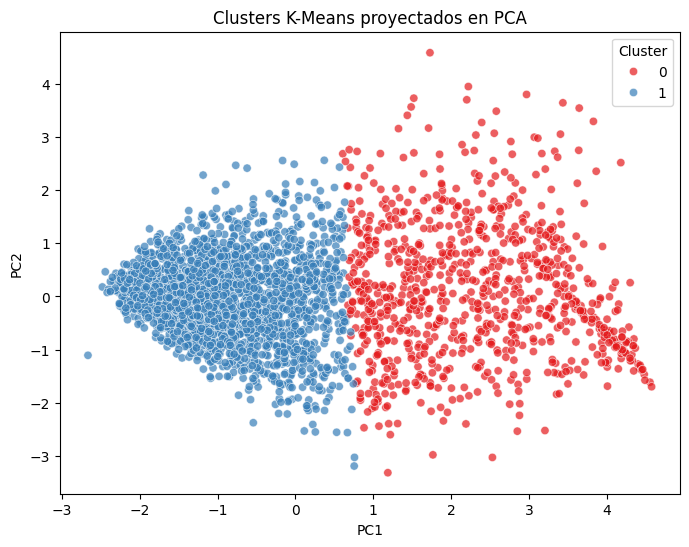

In [187]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=cluster_kmeans,
    palette="Set1",
    alpha=0.7
)

plt.title("Clusters K-Means proyectados en PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

## Clustering jerárquico

In [188]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [189]:
muestra_pca = X_pca.sample(
    n=min(500, len(X_pca)),
    random_state=42
)

In [190]:
matriz_linkage = linkage(
    muestra_pca,
    method="ward"
)

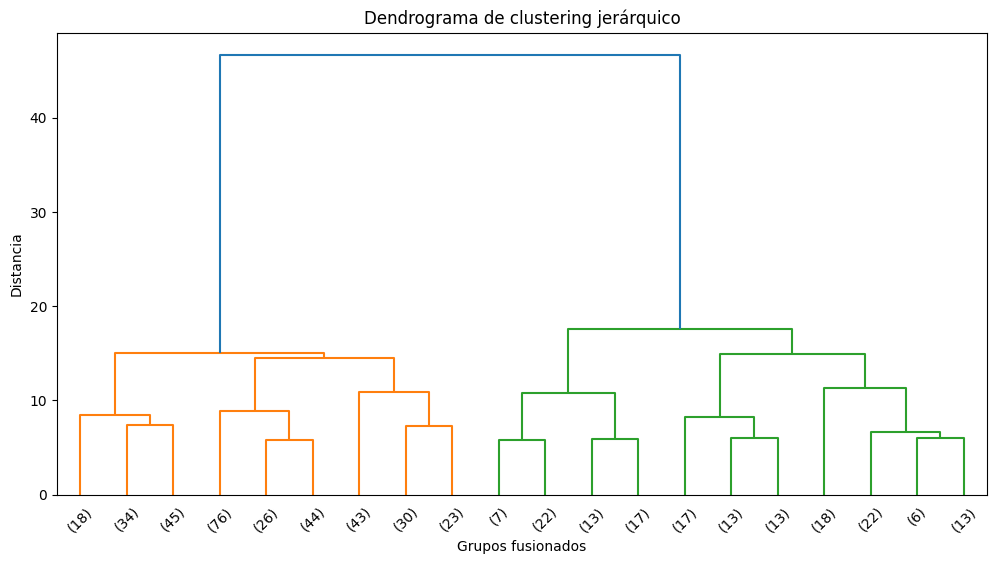

In [191]:
plt.figure(figsize=(12, 6))

dendrogram(
    matriz_linkage,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Dendrograma de clustering jerárquico")
plt.xlabel("Grupos fusionados")
plt.ylabel("Distancia")
plt.show()

In [192]:
modelo_jerarquico = AgglomerativeClustering(
    n_clusters=k_optimo,
    linkage="ward"
)

cluster_jerarquico = modelo_jerarquico.fit_predict(X_pca)

In [193]:
df_cluster["Cluster_Jerarquico"] = cluster_jerarquico

In [194]:
df_cluster["Cluster_Jerarquico"].value_counts().sort_index()

Cluster_Jerarquico
0    1176
1    1824
Name: count, dtype: int64

In [195]:
sil_jerarquico = silhouette_score(
    X_pca,
    cluster_jerarquico
)

cal_jerarquico = calinski_harabasz_score(
    X_pca,
    cluster_jerarquico
)

dav_jerarquico = davies_bouldin_score(
    X_pca,
    cluster_jerarquico
)

print(f"Silhouette Jerárquico: {sil_jerarquico:.4f}")
print(f"Calinski-Harabasz Jerárquico: {cal_jerarquico:.4f}")
print(f"Davies-Bouldin Jerárquico: {dav_jerarquico:.4f}")

Silhouette Jerárquico: 0.3119
Calinski-Harabasz Jerárquico: 1508.7421
Davies-Bouldin Jerárquico: 1.3496


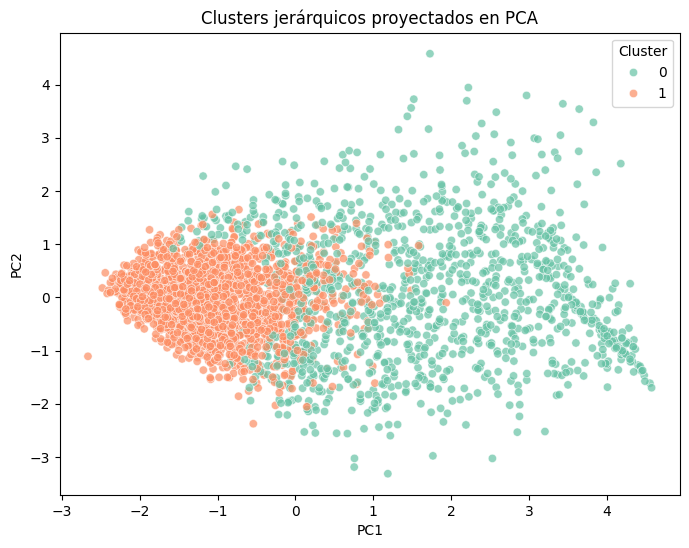

In [196]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=cluster_jerarquico,
    palette="Set2",
    alpha=0.7
)

plt.title("Clusters jerárquicos proyectados en PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

## DBSCAN

In [197]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [198]:
min_samples = 10

vecinos = NearestNeighbors(
    n_neighbors=min_samples
)

vecinos.fit(X_pca)

distancias, indices = vecinos.kneighbors(X_pca)

distancias_ordenadas = np.sort(
    distancias[:, -1]
)

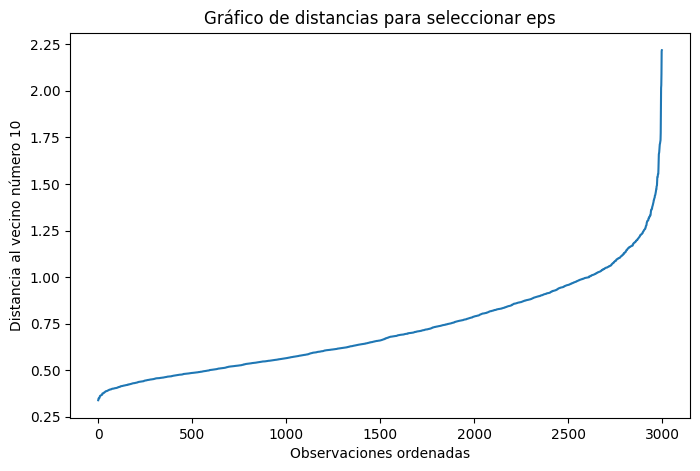

In [199]:
plt.figure(figsize=(8, 5))

plt.plot(distancias_ordenadas)

plt.title("Gráfico de distancias para seleccionar eps")
plt.xlabel("Observaciones ordenadas")
plt.ylabel(f"Distancia al vecino número {min_samples}")
plt.show()

In [200]:
modelo_dbscan = DBSCAN(
    eps=1.5,
    min_samples=min_samples
)

cluster_dbscan = modelo_dbscan.fit_predict(X_pca)

In [201]:
pd.Series(cluster_dbscan).value_counts().sort_index()

-1       5
 0    2995
Name: count, dtype: int64

In [202]:
df_cluster["Cluster_DBSCAN"] = cluster_dbscan

In [203]:
n_clusters_dbscan = len(
    set(cluster_dbscan)
) - (1 if -1 in cluster_dbscan else 0)

n_ruido = np.sum(cluster_dbscan == -1)

print("Clusters DBSCAN:", n_clusters_dbscan)
print("Observaciones clasificadas como ruido:", n_ruido)
print(f"Porcentaje de ruido: {n_ruido / len(cluster_dbscan) * 100:.2f}%")

Clusters DBSCAN: 1
Observaciones clasificadas como ruido: 5
Porcentaje de ruido: 0.17%


In [205]:
mascara_dbscan = cluster_dbscan != -1

etiquetas_sin_ruido = cluster_dbscan[mascara_dbscan]
datos_sin_ruido = X_pca.loc[mascara_dbscan]

In [206]:
if len(np.unique(etiquetas_sin_ruido)) >= 2:

    sil_dbscan = silhouette_score(
        datos_sin_ruido,
        etiquetas_sin_ruido
    )

    cal_dbscan = calinski_harabasz_score(
        datos_sin_ruido,
        etiquetas_sin_ruido
    )

    dav_dbscan = davies_bouldin_score(
        datos_sin_ruido,
        etiquetas_sin_ruido
    )

    print(f"Silhouette DBSCAN: {sil_dbscan:.4f}")
    print(f"Calinski-Harabasz DBSCAN: {cal_dbscan:.4f}")
    print(f"Davies-Bouldin DBSCAN: {dav_dbscan:.4f}")

else:

    sil_dbscan = np.nan
    cal_dbscan = np.nan
    dav_dbscan = np.nan

    print("DBSCAN no encontró al menos dos clusters válidos.")

DBSCAN no encontró al menos dos clusters válidos.


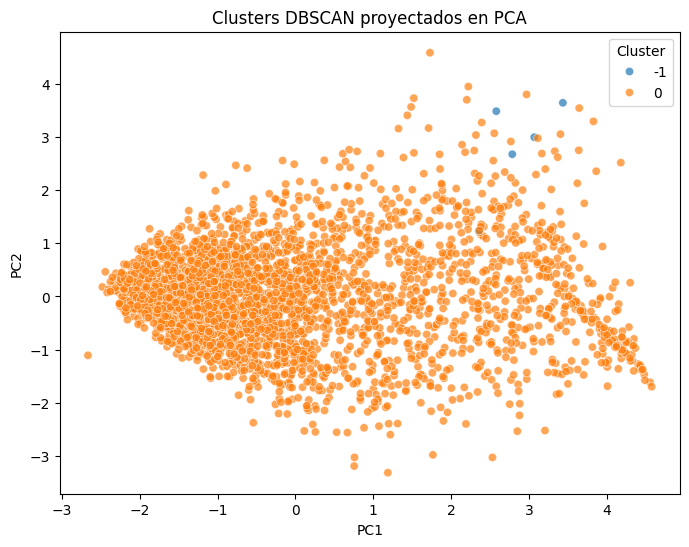

In [208]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=cluster_dbscan,
    palette="tab10",
    alpha=0.7
)

plt.title("Clusters DBSCAN proyectados en PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# Comparación de los tres métodos

In [209]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "K-Means",
        "Jerárquico",
        "DBSCAN"
    ],
    "Silhouette": [
        sil_kmeans,
        sil_jerarquico,
        sil_dbscan
    ],
    "Calinski-Harabasz": [
        cal_kmeans,
        cal_jerarquico,
        cal_dbscan
    ],
    "Davies-Bouldin": [
        dav_kmeans,
        dav_jerarquico,
        dav_dbscan
    ]
})

comparacion_modelos

,Modelo,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.41,"2,091.71",1.10
1,Jerárquico,0.31,"1,508.74",1.35
2,DBSCAN,NaN,NaN,NaN


## Comparar similitud entre K-Means y jerárquico

In [210]:
from sklearn.metrics import adjusted_rand_score

In [211]:
ari_kmeans_jerarquico = adjusted_rand_score(
    cluster_kmeans,
    cluster_jerarquico
)

print(
    f"Adjusted Rand Index K-Means vs Jerárquico: "
    f"{ari_kmeans_jerarquico:.4f}"
)

Adjusted Rand Index K-Means vs Jerárquico: 0.5278


Se compararon tres algoritmos de clustering: K-Means, clustering jerárquico y DBSCAN. La evaluación se realizó mediante los índices Silhouette, Calinski-Harabasz y Davies-Bouldin.

Los resultados muestran que K-Means obtuvo el mejor desempeño, alcanzando el mayor índice Silhouette (0.41), el mayor índice de Calinski-Harabasz (2091.71) y el menor índice de Davies-Bouldin (1.10). Estos resultados indican que los grupos obtenidos presentan una mejor cohesión interna y una mayor separación entre ellos.

Por otra parte, el clustering jerárquico obtuvo un desempeño inferior en las tres métricas, mientras que DBSCAN no logró identificar una estructura de densidad que permitiera formar clusters válidos.

Por estas razones, el algoritmo seleccionado para el análisis de perfiles de clientes será K-Means

# Perfilamiento de Clusters y Validación Externa

In [212]:
perfil = (
    df_cluster
    .groupby("Cluster_KMeans")
    .agg({
        "Edad":"mean",
        "Ingreso_Promedio":"mean",
        "Deuda_Total":"mean",
        "Ratio_Endeudamiento":"mean",
        "AgnosEmpleo":"mean",
        "AgnosDirec":"mean"
    })
    .round(2)
)

perfil

,Edad,Ingreso_Promedio,Deuda_Total,Ratio_Endeudamiento,AgnosEmpleo,AgnosDirec
Cluster_KMeans,,,,,,
0,39.95,"88,413.55","11,515.46",0.15,12.06,11.35
1,35.85,"40,864.51","2,707.54",0.07,4.89,4.98


In [213]:
df_cluster["Cluster_KMeans"].value_counts().sort_index()

Cluster_KMeans
0     858
1    2142
Name: count, dtype: int64

In [214]:
pd.crosstab(
    df_cluster["Cluster_KMeans"],
    df_cluster["VarObj"],
    margins=True
)

VarObj,N,S,All
Cluster_KMeans,,,
0,627,231,858
1,1736,406,2142
All,2363,637,3000


In [215]:
pd.crosstab(
    df_cluster["Cluster_KMeans"],
    df_cluster["VarObj"],
    normalize="index"
).round(3)

VarObj,N,S
Cluster_KMeans,,
0,0.73,0.27
1,0.81,0.19


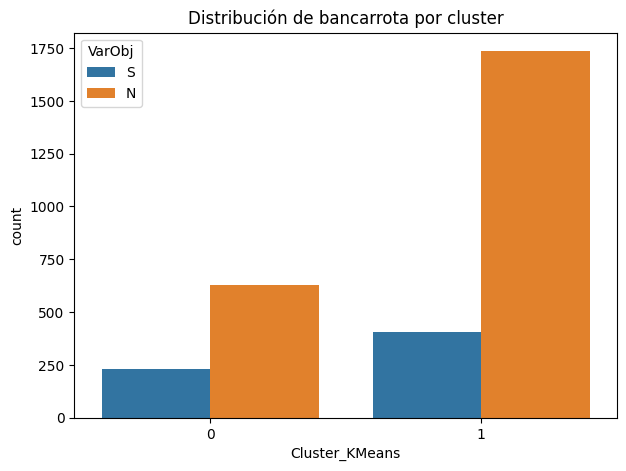

In [216]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_cluster,
    x="Cluster_KMeans",
    hue="VarObj"
)

plt.title("Distribución de bancarrota por cluster")

plt.show()

In [217]:
perfil_normalizado = (
    perfil - perfil.min()
) / (
    perfil.max() - perfil.min()
)

perfil_normalizado

,Edad,Ingreso_Promedio,Deuda_Total,Ratio_Endeudamiento,AgnosEmpleo,AgnosDirec
Cluster_KMeans,,,,,,
0,1.00,1.00,1.00,1.00,1.00,1.00
1,0.00,0.00,0.00,0.00,0.00,0.00


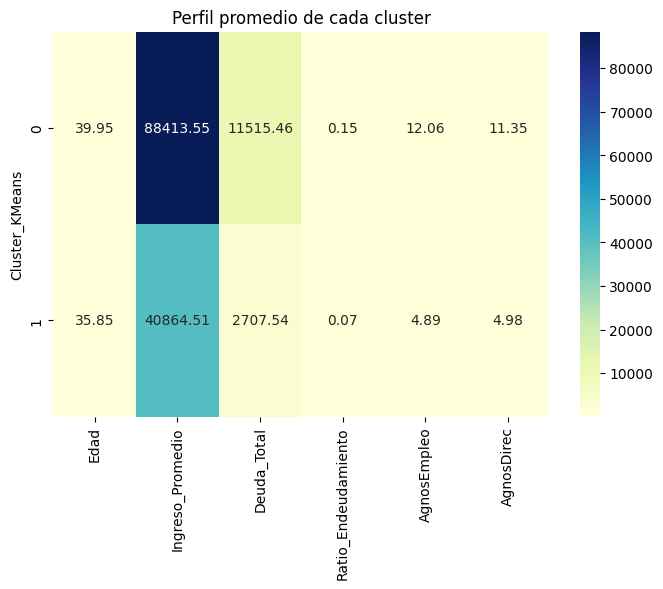

In [218]:
plt.figure(figsize=(8,5))

sns.heatmap(
    perfil,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Perfil promedio de cada cluster")

plt.show()

In [219]:
porcentaje_varobj = (
    pd.crosstab(
        df_cluster["Cluster_KMeans"],
        df_cluster["VarObj"],
        normalize="index"
    ) * 100
).round(2)

porcentaje_varobj

VarObj,N,S
Cluster_KMeans,,
0,73.08,26.92
1,81.05,18.95


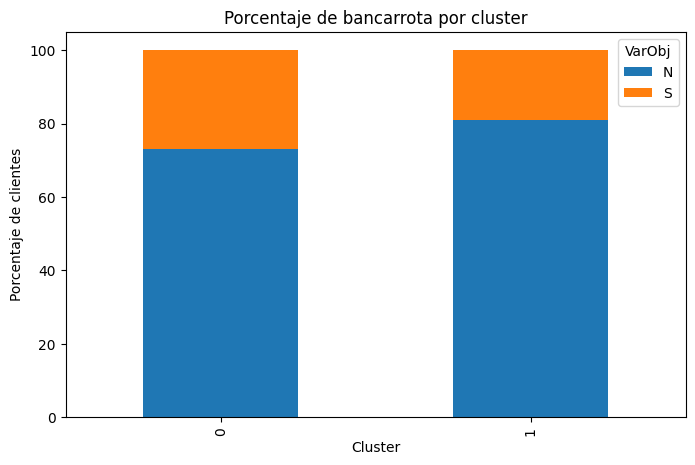

In [220]:
tabla = (
    pd.crosstab(
        df_cluster["Cluster_KMeans"],
        df_cluster["VarObj"],
        normalize="index"
    ) * 100
)

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Porcentaje de clientes")
plt.xlabel("Cluster")
plt.title("Porcentaje de bancarrota por cluster")

plt.legend(title="VarObj")

plt.show()

Para evaluar la utilidad de la segmentación, se comparó cada cluster con la variable VarObj, que indica si el cliente presentó bancarrota.

Los resultados muestran que el Cluster 0 concentra aproximadamente un 26,9% de clientes con bancarrota, mientras que el Cluster 1 presenta alrededor de un 19,0%. Esto indica que existe una diferencia cercana a 8 puntos porcentuales entre ambos grupos.

Estos resultados sugieren que la segmentación obtenida mediante K-Means es útil para diferenciar perfiles de riesgo. En particular, el Cluster 0 reúne clientes con mayores ingresos, mayores niveles de deuda y un mayor ratio de endeudamiento, características que también se asocian con una mayor probabilidad de bancarrota en este conjunto de datos.

Aunque los clusters no permiten identificar con certeza qué clientes quebrarán, sí constituyen una herramienta útil para clasificar a los clientes según su nivel de riesgo y apoyar la toma de decisiones del banco en la evaluación y monitoreo de solicitudes de crédito.

# Detección de Anomalías (Complemento)

In [222]:
from sklearn.ensemble import IsolationForest

In [223]:
modelo_if = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomalias = modelo_if.fit_predict(X_preparado)

In [224]:
df_cluster["Anomalia"] = np.where(
    anomalias == -1,
    "Sí",
    "No"
)

In [225]:
df_cluster["Anomalia"].value_counts()

Anomalia
No    2850
Sí     150
Name: count, dtype: int64

In [226]:
(
    df_cluster["Anomalia"]
    .value_counts(normalize=True)
    *100
).round(2)

Anomalia
No   95.00
Sí    5.00
Name: proportion, dtype: float64

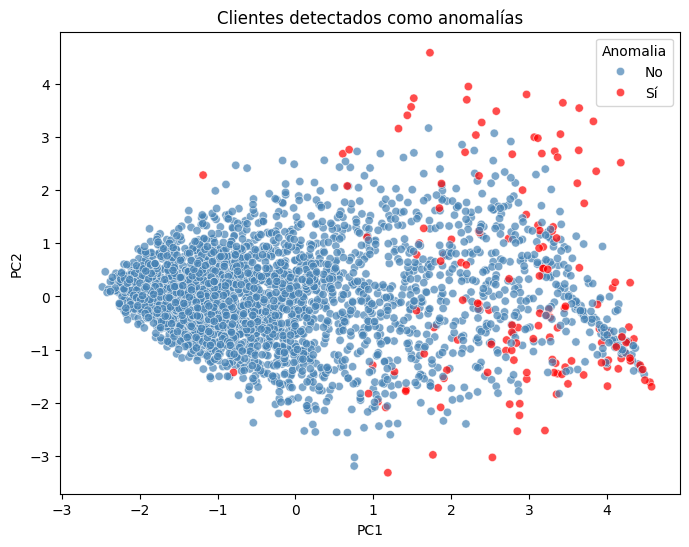

In [227]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=df_cluster["Anomalia"],
    palette={
        "No":"steelblue",
        "Sí":"red"
    },
    alpha=0.7
)

plt.title("Clientes detectados como anomalías")

plt.show()

In [228]:
pd.crosstab(
    df_cluster["Anomalia"],
    df_cluster["VarObj"],
    margins=True
)

VarObj,N,S,All
Anomalia,,,
No,2243,607,2850
Sí,120,30,150
All,2363,637,3000


In [229]:
(
    pd.crosstab(
        df_cluster["Anomalia"],
        df_cluster["VarObj"],
        normalize="index"
    )*100
).round(2)

VarObj,N,S
Anomalia,,
No,78.70,21.30
Sí,80.00,20.00


In [230]:
perfil_anomalias = (
    df_cluster
    .groupby("Anomalia")
    .agg({
        "Ingreso_Promedio":"mean",
        "Deuda_Total":"mean",
        "Ratio_Endeudamiento":"mean",
        "Edad":"mean"
    })
    .round(2)
)

perfil_anomalias

,Ingreso_Promedio,Deuda_Total,Ratio_Endeudamiento,Edad
Anomalia,,,,
No,"52,537.35","4,846.21",0.09,36.73
Sí,"91,061.10","12,454.11",0.18,42.46


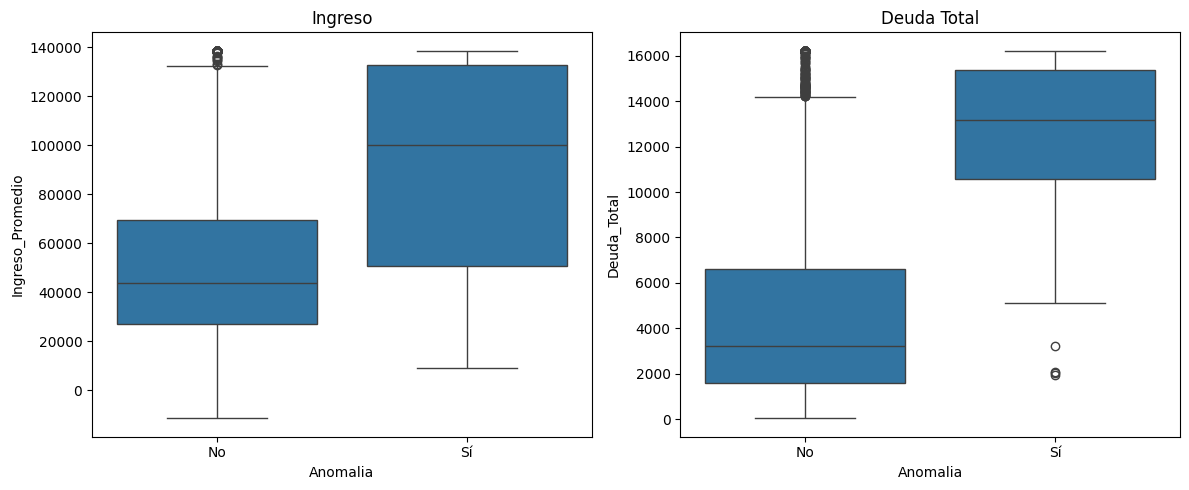

In [231]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    data=df_cluster,
    x="Anomalia",
    y="Ingreso_Promedio",
    ax=axes[0]
)

axes[0].set_title("Ingreso")

sns.boxplot(
    data=df_cluster,
    x="Anomalia",
    y="Deuda_Total",
    ax=axes[1]
)

axes[1].set_title("Deuda Total")

plt.tight_layout()

plt.show()

Isolation Forest identificó un pequeño grupo de clientes con características financieras distintas al resto de la muestra. Estos clientes presentan patrones poco frecuentes considerando simultáneamente variables como ingresos, nivel de deuda, edad y antigüedad laboral.

La comparación con la variable VarObj permite evaluar si las observaciones clasificadas como anomalías presentan una mayor proporción de bancarrota. Si esta proporción resulta superior a la observada en los clientes normales, las anomalías podrían representar perfiles de mayor riesgo y constituir un apoyo adicional para el proceso de evaluación crediticia.

No obstante, es importante considerar que una anomalía no implica necesariamente que un cliente vaya a presentar incumplimiento, sino que su comportamiento financiero difiere del patrón predominante en la base de datos.

# Conclusión y recomendación final

Se realizó un proceso completo de segmentación de clientes utilizando técnicas de aprendizaje no supervisado. Después de preparar los datos mediante imputación de valores faltantes, tratamiento de valores extremos, creación de variables derivadas, codificación de variables categóricas y escalamiento con RobustScaler, se aplicó PCA para reducir la dimensionalidad del problema.

La comparación entre distintos algoritmos mostró que K-Means obtuvo el mejor desempeño, alcanzando los mejores resultados en los índices Silhouette, Calinski-Harabasz y Davies-Bouldin. La solución de dos clusters permitió identificar perfiles financieros claramente diferenciados.

El análisis de los clusters evidenció que uno de ellos concentra clientes con mayores ingresos, mayor nivel de endeudamiento y una mayor proporción de bancarrota, mientras que el otro agrupa clientes con menores niveles de deuda y menor riesgo de incumplimiento.

Finalmente, Isolation Forest permitió identificar clientes con características financieras atípicas, los cuales pueden representar casos que requieren una evaluación adicional por parte del banco.

En conjunto, estos resultados muestran que las técnicas de aprendizaje no supervisado constituyen una herramienta útil para apoyar la segmentación de clientes y complementar los procesos tradicionales de evaluación de riesgo crediticio.